# CXR-LT 2023

This notebook is organized around a few questions that make the dataset easier to reason about before modeling:

- How large is each split, and is there any subject/study leakage?
- Which labels are common, which are truly rare, and how long-tailed is the problem?
- How many findings does each image usually carry?
- Which view positions dominate the dataset, and how much metadata is missing?
- Do the sample submission files match the training label schema?


In [27]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import display

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 100)
pd.set_option("display.max_rows", 100)

cwd = Path.cwd()
if cwd.name != "00-examine-data":
    raise Exception("Please run this notebook from the 00-examine-data directory")

root_dir = cwd.parents[1]
data_dir = root_dir / "data"
cxr_lt_2023_dir = data_dir / "CXR-LT" / "cxr-lt-multi-label-long-tailed-classification-on-chest-x-rays-2.0.0" / "cxr-lt-2023"

print(root_dir)
print(cxr_lt_2023_dir)


/home/tungnguyen/Programming/Chest-Medical-Image-Fusion-for-Multimodal-Clinical-Analysis
/home/tungnguyen/Programming/Chest-Medical-Image-Fusion-for-Multimodal-Clinical-Analysis/data/CXR-LT/cxr-lt-multi-label-long-tailed-classification-on-chest-x-rays-2.0.0/cxr-lt-2023


In [28]:
CSV_FILES = {
    "train": "train.csv",
    "development": "development.csv",
    "test": "test.csv",
    "development_sample_submission": "development_sample_submission.csv",
    "test_sample_submission": "test_sample_submission.csv",
}

ID_COLUMNS = [
    "dicom_id",
    "subject_id",
    "study_id",
    "ViewPosition",
    "ViewCodeSequence_CodeMeaning",
    "path",
]


def load_dataset(filename: str) -> pd.DataFrame:
    return pd.read_csv(cxr_lt_2023_dir / filename)


datasets = {name: load_dataset(filename) for name, filename in CSV_FILES.items()}

train_df = datasets["train"]
dev_df = datasets["development"]
test_df = datasets["test"]
dev_sample_sub_df = datasets["development_sample_submission"]
test_sample_sub_df = datasets["test_sample_submission"]

analysis_splits = {
    "train": train_df,
    "development": dev_df,
    "test": test_df,
}

submission_splits = {
    "development_sample_submission": dev_sample_sub_df,
    "test_sample_submission": test_sample_sub_df,
}

label_cols = [column for column in train_df.columns if column not in ID_COLUMNS]

print(f"Loaded {len(datasets)} files")
print(f"Detected {len(label_cols)} labels")
label_cols


Loaded 5 files
Detected 26 labels


['Atelectasis',
 'Calcification of the Aorta',
 'Cardiomegaly',
 'Consolidation',
 'Edema',
 'Emphysema',
 'Enlarged Cardiomediastinum',
 'Fibrosis',
 'Fracture',
 'Hernia',
 'Infiltration',
 'Lung Lesion',
 'Lung Opacity',
 'Mass',
 'No Finding',
 'Nodule',
 'Pleural Effusion',
 'Pleural Other',
 'Pleural Thickening',
 'Pneumomediastinum',
 'Pneumonia',
 'Pneumoperitoneum',
 'Pneumothorax',
 'Subcutaneous Emphysema',
 'Support Devices',
 'Tortuous Aorta']

## Reusable helpers

The goal here is to keep the notebook exploratory without repeating the same summary code for every split.


In [29]:
def preview_dataset(name: str, df: pd.DataFrame, head_rows: int = 3) -> None:
    print(f"\n{name}")
    print(f"shape: {df.shape}")
    print(f"duplicate dicom_id rows: {df['dicom_id'].duplicated().sum()}")
    display(df.head(head_rows))

    missing = (
        df.isna().sum()
        .rename("missing_count")
        .loc[lambda series: series > 0]
        .sort_values(ascending=False)
    )
    if missing.empty:
        print("No missing values detected.")
    else:
        missing_df = missing.to_frame().assign(
            missing_pct=lambda frame: frame["missing_count"] / len(df) * 100
        )
        display(missing_df)


def build_split_overview(split_frames: dict[str, pd.DataFrame], label_columns: list[str]) -> pd.DataFrame:
    rows = []
    for split_name, df in split_frames.items():
        positive_labels_per_image = df[label_columns].sum(axis=1)
        rows.append(
            {
                "split": split_name,
                "rows": len(df),
                "unique_subjects": df["subject_id"].nunique(),
                "unique_studies": df["study_id"].nunique(),
                "unique_dicoms": df["dicom_id"].nunique(),
                "missing_ViewPosition": df["ViewPosition"].isna().sum(),
                "missing_ViewCodeMeaning": df["ViewCodeSequence_CodeMeaning"].isna().sum(),
                "avg_labels_per_image": positive_labels_per_image.mean(),
                "median_labels_per_image": positive_labels_per_image.median(),
                "no_finding_rate_pct": df["No Finding"].mean() * 100,
            }
        )

    return pd.DataFrame(rows).sort_values("rows", ascending=False).reset_index(drop=True)


def summarize_labels(df: pd.DataFrame, split_name: str, label_columns: list[str]) -> pd.DataFrame:
    summary = (
        df[label_columns]
        .mean()
        .mul(100)
        .rename("positive_rate_pct")
        .sort_values(ascending=False)
        .reset_index()
        .rename(columns={"index": "label"})
    )
    summary.insert(0, "split", split_name)
    summary["positive_count"] = summary["label"].map(df[label_columns].sum().to_dict()).astype(int)
    return summary[["split", "label", "positive_count", "positive_rate_pct"]]


def plot_label_prevalence(split_frames: dict[str, pd.DataFrame], label_columns: list[str], top_n: int = 15) -> None:
    label_summary = pd.concat(
        [summarize_labels(df, split_name, label_columns) for split_name, df in split_frames.items()],
        ignore_index=True,
    )

    label_order = (
        label_summary.query("split == 'train'")
        .sort_values("positive_rate_pct", ascending=False)
        .head(top_n)["label"]
    )

    plot_df = label_summary[label_summary["label"].isin(label_order)]

    plt.figure(figsize=(10, 7))
    sns.barplot(
        data=plot_df,
        x="positive_rate_pct",
        y="label",
        hue="split",
        order=label_order,
    )
    plt.title(f"Top {top_n} labels by prevalence in train")
    plt.xlabel("Positive rate (%)")
    plt.ylabel("")
    plt.tight_layout()
    plt.show()


def plot_labels_per_image(split_frames: dict[str, pd.DataFrame], label_columns: list[str]) -> None:
    fig, axes = plt.subplots(1, len(split_frames), figsize=(15, 4), sharey=True)

    for ax, (split_name, df) in zip(axes, split_frames.items()):
        label_counts = df[label_columns].sum(axis=1).astype(int)
        counts = label_counts.value_counts().sort_index()
        ax.bar(counts.index, counts.values)
        ax.set_title(split_name)
        ax.set_xlabel("Positive labels per image")
        ax.set_ylabel("Image count")

    plt.tight_layout()
    plt.show()


def summarize_view_positions(df: pd.DataFrame, split_name: str, top_n: int = 8) -> pd.DataFrame:
    view_counts = (
        df["ViewPosition"]
        .fillna("Missing")
        .value_counts()
        .head(top_n)
        .rename_axis("ViewPosition")
        .reset_index(name="count")
    )
    view_counts.insert(0, "split", split_name)
    view_counts["rate_pct"] = view_counts["count"] / len(df) * 100
    return view_counts


def plot_view_positions(split_frames: dict[str, pd.DataFrame], top_n: int = 6) -> None:
    plot_df = pd.concat(
        [summarize_view_positions(df, split_name, top_n=top_n) for split_name, df in split_frames.items()],
        ignore_index=True,
    )

    plt.figure(figsize=(11, 5))
    sns.barplot(data=plot_df, x="ViewPosition", y="rate_pct", hue="split")
    plt.title(f"Top {top_n} view positions by split")
    plt.xlabel("")
    plt.ylabel("Rate (%)")
    plt.xticks(rotation=20)
    plt.tight_layout()
    plt.show()


def compute_overlap(split_frames: dict[str, pd.DataFrame], key: str) -> pd.DataFrame:
    split_names = list(split_frames)
    key_sets = {split_name: set(df[key]) for split_name, df in split_frames.items()}

    overlap_matrix = pd.DataFrame(index=split_names, columns=split_names, dtype=int)
    for left_name in split_names:
        for right_name in split_names:
            overlap_matrix.loc[left_name, right_name] = len(key_sets[left_name] & key_sets[right_name])

    return overlap_matrix


def summarize_no_finding_conflicts(split_frames: dict[str, pd.DataFrame], label_columns: list[str]) -> pd.DataFrame:
    other_labels = [label for label in label_columns if label != "No Finding"]
    rows = []

    for split_name, df in split_frames.items():
        conflicts = ((df["No Finding"] == 1) & (df[other_labels].sum(axis=1) > 0)).sum()
        rows.append(
            {
                "split": split_name,
                "rows_with_no_finding": int(df["No Finding"].sum()),
                "rows_with_no_finding_and_other_label": int(conflicts),
                "conflict_rate_within_no_finding_pct": conflicts / max(df["No Finding"].sum(), 1) * 100,
            }
        )

    return pd.DataFrame(rows)


def summarize_submission_file(df: pd.DataFrame, split_name: str, label_columns: list[str]) -> pd.DataFrame:
    submission_label_columns = [column for column in df.columns if column != "dicom_id"]
    rows = [
        {
            "split": split_name,
            "rows": len(df),
            "label_columns_match_train": submission_label_columns == label_columns,
            "min_score": df[submission_label_columns].min().min(),
            "mean_score": df[submission_label_columns].mean().mean(),
            "max_score": df[submission_label_columns].max().max(),
        }
    ]
    return pd.DataFrame(rows)


## 1) Quick split overview

Start here to answer: how big are the splits, what fields exist, and where is metadata incomplete?


In [30]:
for split_name, df in analysis_splits.items():
    preview_dataset(split_name, df)

split_overview_df = build_split_overview(analysis_splits, label_cols)
display(split_overview_df)



train
shape: (264849, 32)
duplicate dicom_id rows: 0


,dicom_id,subject_id,study_id,ViewPosition,ViewCodeSequence_CodeMeaning,path,Atelectasis,Calcification of the Aorta,Cardiomegaly,Consolidation,Edema,Emphysema,Enlarged Cardiomediastinum,Fibrosis,Fracture,Hernia,Infiltration,Lung Lesion,Lung Opacity,Mass,No Finding,Nodule,Pleural Effusion,Pleural Other,Pleural Thickening,Pneumomediastinum,Pneumonia,Pneumoperitoneum,Pneumothorax,Subcutaneous Emphysema,Support Devices,Tortuous Aorta
0,02aa804e-bde0afdd-112c0b34-7bc16630-4e384014,10000032,50414267,PA,postero-anterior,files/p10/p10000032/s50414267/02aa804e-bde0afd...,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,1,0,0,0,0,1,0,0,0,0,0
1,174413ec-4ec4c1f7-34ea26b7-c5f994f8-79ef1962,10000032,50414267,LATERAL,lateral,files/p10/p10000032/s50414267/174413ec-4ec4c1f...,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,1,0,0,0,0,1,0,0,0,0,0
2,2a2277a9-b0ded155-c0de8eb9-c124d10e-82c5caab,10000032,53189527,PA,postero-anterior,files/p10/p10000032/s53189527/2a2277a9-b0ded15...,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0


,missing_count,missing_pct
ViewCodeSequence_CodeMeaning,11526,4.351914
ViewPosition,11050,4.172189



development
shape: (36769, 32)
duplicate dicom_id rows: 0


,dicom_id,subject_id,study_id,ViewPosition,ViewCodeSequence_CodeMeaning,path,Atelectasis,Calcification of the Aorta,Cardiomegaly,Consolidation,Edema,Emphysema,Enlarged Cardiomediastinum,Fibrosis,Fracture,Hernia,Infiltration,Lung Lesion,Lung Opacity,Mass,No Finding,Nodule,Pleural Effusion,Pleural Other,Pleural Thickening,Pneumomediastinum,Pneumonia,Pneumoperitoneum,Pneumothorax,Subcutaneous Emphysema,Support Devices,Tortuous Aorta
0,2833b85f-3bb4273f-cffd3794-2bf2cd57-7ddb3f5f,10002177,50520012,PA,postero-anterior,files/p10/p10002177/s50520012/2833b85f-3bb4273...,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0
1,7fdad032-90608fe2-c1f5a700-bf95f6f9-e9b0dbc7,10002177,50520012,LATERAL,lateral,files/p10/p10002177/s50520012/7fdad032-90608fe...,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0
2,8b88f03a-2004113d-4118def5-35820db5-d0913df8,10002221,53781756,NaN,NaN,files/p10/p10002221/s53781756/8b88f03a-2004113...,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0


,missing_count,missing_pct
ViewCodeSequence_CodeMeaning,1564,4.253583
ViewPosition,1494,4.063205



test
shape: (75492, 32)
duplicate dicom_id rows: 0


,dicom_id,subject_id,study_id,ViewPosition,ViewCodeSequence_CodeMeaning,path,Atelectasis,Calcification of the Aorta,Cardiomegaly,Consolidation,Edema,Emphysema,Enlarged Cardiomediastinum,Fibrosis,Fracture,Hernia,Infiltration,Lung Lesion,Lung Opacity,Mass,No Finding,Nodule,Pleural Effusion,Pleural Other,Pleural Thickening,Pneumomediastinum,Pneumonia,Pneumoperitoneum,Pneumothorax,Subcutaneous Emphysema,Support Devices,Tortuous Aorta
0,d0b71acc-b5a62046-bbb5f6b8-7b173b85-65cdf738,10000935,50578979,AP,antero-posterior,files/p10/p10000935/s50578979/d0b71acc-b5a6204...,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,1,1,0,0,0,0,0,0,0,0,0
1,3be619d1-506a66cf-ff1ab8a1-2efb77bb-fe7d59fc,10000935,51178377,LATERAL,lateral,files/p10/p10000935/s51178377/3be619d1-506a66c...,0,0,0,0,0,0,1,0,0,0,0,0,1,0,0,1,0,0,0,0,0,0,0,0,0,0
2,9b314ad7-fbcb0422-6db62dfc-732858d0-a5527d8b,10000935,51178377,AP,antero-posterior,files/p10/p10000935/s51178377/9b314ad7-fbcb042...,0,0,0,0,0,0,1,0,0,0,0,0,1,0,0,1,0,0,0,0,0,0,0,0,0,0


,missing_count,missing_pct
ViewCodeSequence_CodeMeaning,3407,4.513061
ViewPosition,3225,4.271976


,split,rows,unique_subjects,unique_studies,unique_dicoms,missing_ViewPosition,missing_ViewCodeMeaning,avg_labels_per_image,median_labels_per_image,no_finding_rate_pct
0,train,264849,45766,160052,264849,11050,11526,2.399329,2.0,15.808631
1,test,75492,13075,45492,75492,3225,3407,2.401619,2.0,15.920892
2,development,36769,6538,22291,36769,1494,1564,2.398080,2.0,15.844869


## 2) Label imbalance and multi-label density

This is the part that tells you why the task is called long-tailed. Pay attention to the rarest labels and to how many findings co-occur on each image.


,split,label,positive_count,positive_rate_pct
0,train,Support Devices,89140,33.656914
1,train,Lung Opacity,79931,30.179838
2,train,Cardiomegaly,76900,29.035413
3,train,Pleural Effusion,69240,26.143199
4,train,Atelectasis,67597,25.522845
5,train,Pneumonia,48093,18.158649
6,train,No Finding,41869,15.808631
7,train,Edema,38574,14.564525
8,train,Enlarged Cardiomediastinum,30119,11.372140
9,train,Consolidation,16038,6.055526


,split,label,positive_count,positive_rate_pct
16,train,Emphysema,4255,1.606576
17,train,Hernia,4049,1.528796
18,train,Tortuous Aorta,3499,1.321130
19,train,Pleural Thickening,3369,1.272046
20,train,Lung Lesion,2533,0.956394
21,train,Subcutaneous Emphysema,2453,0.926188
22,train,Fibrosis,1158,0.437230
23,train,Pneumomediastinum,788,0.297528
24,train,Pleural Other,675,0.254862
25,train,Pneumoperitoneum,543,0.205022


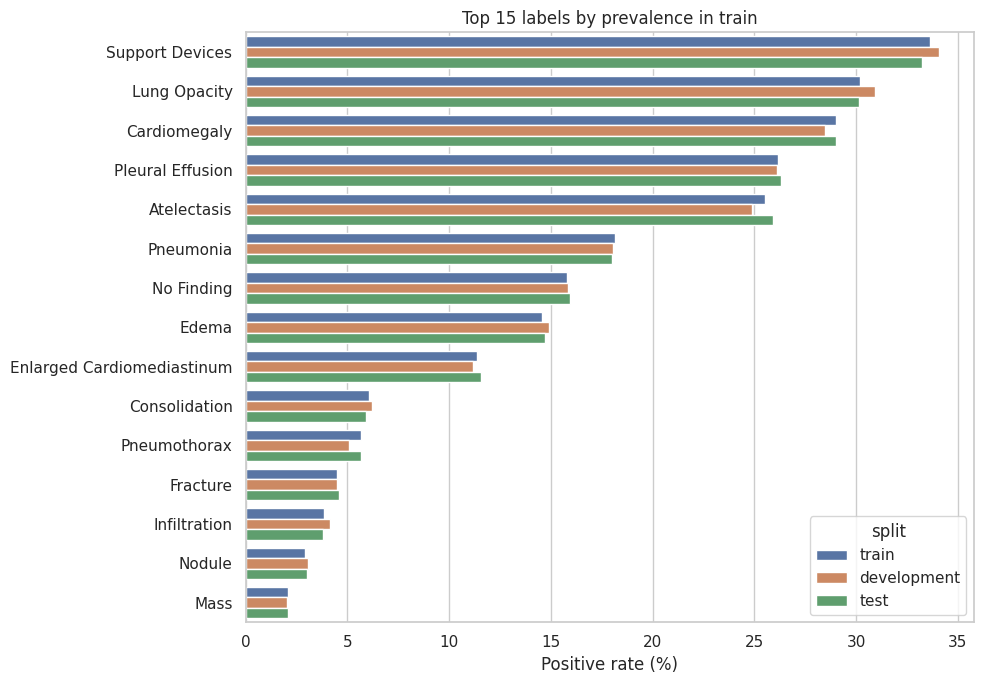

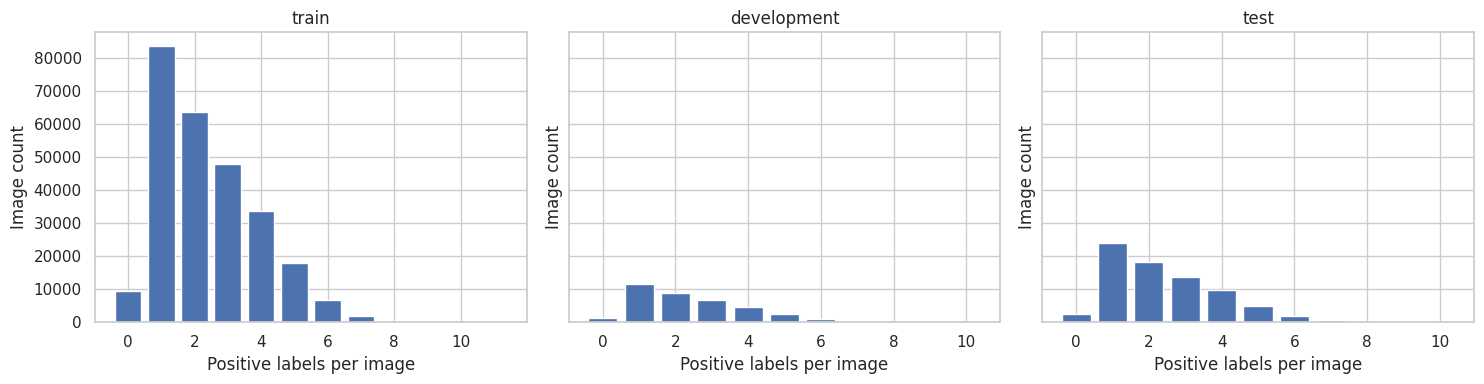

,split,rows_with_no_finding,rows_with_no_finding_and_other_label,conflict_rate_within_no_finding_pct
0,train,41869,7748,18.505338
1,development,5826,1136,19.498798
2,test,12019,2247,18.695399


In [31]:
label_summary_df = pd.concat(
    [summarize_labels(df, split_name, label_cols) for split_name, df in analysis_splits.items()],
    ignore_index=True,
)

display(label_summary_df.query("split == 'train'").head(10))
display(label_summary_df.query("split == 'train'").tail(10))

plot_label_prevalence(analysis_splits, label_cols, top_n=15)
plot_labels_per_image(analysis_splits, label_cols)

display(summarize_no_finding_conflicts(analysis_splits, label_cols))


## 3) View metadata and split leakage checks

For modeling, it helps to know whether view-position distribution shifts across splits and whether the same patient or study appears in multiple splits.


,split,ViewPosition,count,rate_pct
0,train,AP,103312,39.007888
1,train,PA,67559,25.508497
2,train,LATERAL,58018,21.906067
3,train,LL,24894,9.399318
4,train,Missing,11050,4.172189
5,train,PA LLD,4,0.001510
6,train,LAO,3,0.001133
7,train,RAO,3,0.001133
8,development,AP,14478,39.375561
9,development,PA,9305,25.306644


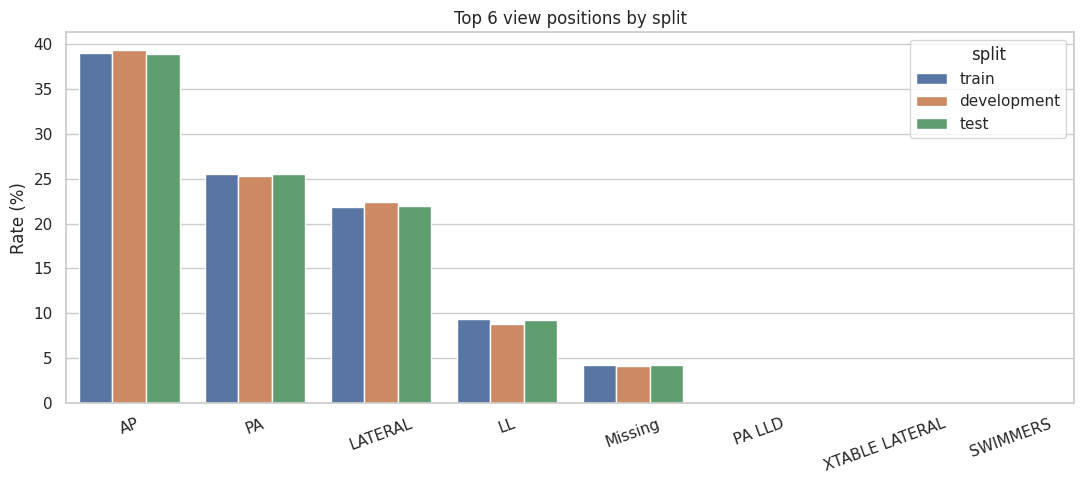


Overlap for subject_id


,train,development,test
train,45766.0,0.0,0.0
development,0.0,6538.0,0.0
test,0.0,0.0,13075.0



Overlap for study_id


,train,development,test
train,160052.0,0.0,0.0
development,0.0,22291.0,0.0
test,0.0,0.0,45492.0



Overlap for dicom_id


,train,development,test
train,264849.0,0.0,0.0
development,0.0,36769.0,0.0
test,0.0,0.0,75492.0


In [32]:
view_position_summary_df = pd.concat(
    [summarize_view_positions(df, split_name) for split_name, df in analysis_splits.items()],
    ignore_index=True,
)
display(view_position_summary_df)
plot_view_positions(analysis_splits, top_n=6)

for overlap_key in ["subject_id", "study_id", "dicom_id"]:
    print(f"\nOverlap for {overlap_key}")
    display(compute_overlap(analysis_splits, overlap_key))


## 4) Sample submission sanity checks

These files are handy for confirming the label order expected by the benchmark and for checking score ranges before writing an inference pipeline.


In [33]:
submission_summary_df = pd.concat(
    [summarize_submission_file(df, split_name, label_cols) for split_name, df in submission_splits.items()],
    ignore_index=True,
)
display(submission_summary_df)

for split_name, df in submission_splits.items():
    print(f"\n{split_name}")
    display(df.head(3))


,split,rows,label_columns_match_train,min_score,mean_score,max_score
0,development_sample_submission,36769,True,2.930000e-05,0.090590,0.99987
1,test_sample_submission,75492,True,2.701845e-07,0.499878,1.00000



development_sample_submission


,dicom_id,Atelectasis,Calcification of the Aorta,Cardiomegaly,Consolidation,Edema,Emphysema,Enlarged Cardiomediastinum,Fibrosis,Fracture,Hernia,Infiltration,Lung Lesion,Lung Opacity,Mass,No Finding,Nodule,Pleural Effusion,Pleural Other,Pleural Thickening,Pneumomediastinum,Pneumonia,Pneumoperitoneum,Pneumothorax,Subcutaneous Emphysema,Support Devices,Tortuous Aorta
0,2833b85f-3bb4273f-cffd3794-2bf2cd57-7ddb3f5f,0.033536,0.000823,0.069515,0.037374,0.018542,0.001762,0.115628,0.000941,0.029183,0.000827,0.034808,0.005435,0.244526,0.008278,0.327484,0.024222,0.059168,0.002028,0.006737,0.009162,0.232550,0.001842,0.066173,0.002313,0.019985,0.001036
1,7fdad032-90608fe2-c1f5a700-bf95f6f9-e9b0dbc7,0.017256,0.001685,0.057716,0.034736,0.011108,0.001892,0.145695,0.001276,0.034275,0.000956,0.026922,0.005146,0.197133,0.008934,0.387699,0.025641,0.027894,0.002538,0.006239,0.008972,0.229188,0.001278,0.037816,0.001514,0.034026,0.000951
2,8b88f03a-2004113d-4118def5-35820db5-d0913df8,0.031781,0.005160,0.091920,0.012458,0.013892,0.001624,0.090124,0.001223,0.049956,0.009194,0.050405,0.008491,0.106392,0.020967,0.374999,0.039554,0.013705,0.002365,0.009213,0.001864,0.210702,0.000764,0.007283,0.000721,0.056302,0.014445



test_sample_submission


,dicom_id,Atelectasis,Calcification of the Aorta,Cardiomegaly,Consolidation,Edema,Emphysema,Enlarged Cardiomediastinum,Fibrosis,Fracture,Hernia,Infiltration,Lung Lesion,Lung Opacity,Mass,No Finding,Nodule,Pleural Effusion,Pleural Other,Pleural Thickening,Pneumomediastinum,Pneumonia,Pneumoperitoneum,Pneumothorax,Subcutaneous Emphysema,Support Devices,Tortuous Aorta
0,d0b71acc-b5a62046-bbb5f6b8-7b173b85-65cdf738,0.044621,0.453646,0.053234,0.914087,0.756277,0.710636,0.201749,0.005243,0.966997,0.786332,0.074850,0.232403,0.734478,0.730561,0.515662,0.441672,0.405095,0.892778,0.269822,0.360429,0.671562,0.752237,0.705626,0.420611,0.795566,0.222684
1,3be619d1-506a66cf-ff1ab8a1-2efb77bb-fe7d59fc,0.436481,0.322232,0.614867,0.201023,0.467760,0.785392,0.591890,0.864125,0.514562,0.455972,0.442398,0.535389,0.228226,0.281679,0.767291,0.243542,0.175613,0.497524,0.063880,0.073988,0.994118,0.822464,0.407094,0.654748,0.909375,0.653350
2,9b314ad7-fbcb0422-6db62dfc-732858d0-a5527d8b,0.240715,0.101297,0.071512,0.349937,0.548107,0.555194,0.098996,0.782660,0.072775,0.165593,0.968731,0.273845,0.745644,0.092066,0.028868,0.997847,0.216771,0.169473,0.513566,0.419945,0.985205,0.264108,0.394382,0.772200,0.690808,0.977312


## What to inspect next

Once this notebook makes sense, the next useful passes are usually:

1. Study-level aggregation: group by `study_id` and check how often a study contains both PA/AP and lateral views.
2. Patient timeline behavior: sort by `subject_id`, `study_id` or acquisition time from MIMIC metadata and inspect repeat exams.
3. Label correlations: compute a co-occurrence matrix to see which findings often appear together.
4. View-conditioned prevalence: compare label frequencies for `AP`, `PA`, and `LATERAL` only.
5. Image availability and path sanity: verify how many `path` entries are actually present on disk before building dataloaders.
6. Text linkage readiness: join these rows against MIMIC report metadata so you can quantify how many studies have usable paired text.
